# Results Analysis

Parsed experiment summary table:


,folder_name,folder_path,model,method,k,variant,summary_file,pass_rate,avg_gini_simpson_idx,total_prompt_tokens,total_resp_tokens,total_tokens,avg_tokens_per_prompt,avg_tokens_per_resp,avg_tokens_per_query,total_cost,label
0,openrouter-gpt35-full-vanilla,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35,vanilla,0,base,verilog-eval-wsl\build\openrouter-gpt35-full-v...,41.03,0.0,42750.0,28063.0,70813.0,274.04,179.89,453.93,0.0,vanilla-k0
1,openrouter-gpt35-full-vanilla-k0,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35,vanilla,0,base,verilog-eval-wsl\build\openrouter-gpt35-full-v...,39.74,0.0,42750.0,28924.0,71674.0,274.04,185.41,459.45,0.0,vanilla-k0
2,openrouter-gpt35-full-vector,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35,vector,0,base,verilog-eval-wsl\build\openrouter-gpt35-full-v...,30.77,0.0,119709.0,31215.0,150924.0,767.37,200.10,967.46,0.0,vector-k0
3,openrouter-gpt35-full-vector-k1-v2,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35,vector,1,v2,verilog-eval-wsl\build\openrouter-gpt35-full-v...,32.69,0.0,66113.0,30537.0,96650.0,423.80,195.75,619.55,0.0,vector-k1-v2
4,openrouter-gpt35-full-vector-k2,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35,vector,2,base,verilog-eval-wsl\build\openrouter-gpt35-full-v...,32.05,0.0,119709.0,31614.0,151323.0,767.37,202.65,970.02,0.0,vector-k2
5,openrouter-gpt35-full-kg,verilog-eval-wsl\build\openrouter-gpt35-full-kg,gpt35,kg,0,base,verilog-eval-wsl\build\openrouter-gpt35-full-k...,28.85,0.0,133051.0,29195.0,162246.0,852.89,187.15,1040.04,0.0,kg-k0
6,openrouter-gpt35-full-kg-k2,verilog-eval-wsl\build\openrouter-gpt35-full-k...,gpt35,kg,2,base,verilog-eval-wsl\build\openrouter-gpt35-full-k...,28.21,0.0,133051.0,28249.0,161300.0,852.89,181.08,1033.97,0.0,kg-k2
7,openrouter-gpt35-full-hybrid,verilog-eval-wsl\build\openrouter-gpt35-full-h...,gpt35,hybrid,0,base,verilog-eval-wsl\build\openrouter-gpt35-full-h...,32.69,0.0,128788.0,29452.0,158240.0,825.56,188.79,1014.36,0.0,hybrid-k0
8,openrouter-gpt35-full-hybrid-k1-v2,verilog-eval-wsl\build\openrouter-gpt35-full-h...,gpt35,hybrid,1,v2,verilog-eval-wsl\build\openrouter-gpt35-full-h...,33.33,0.0,67127.0,26774.0,93901.0,430.30,171.63,601.93,0.0,hybrid-k1-v2
9,openrouter-gpt35-full-hybrid-k2,verilog-eval-wsl\build\openrouter-gpt35-full-h...,gpt35,hybrid,2,base,verilog-eval-wsl\build\openrouter-gpt35-full-h...,35.26,0.0,128788.0,29825.0,158613.0,825.56,191.19,1016.75,0.0,hybrid-k2


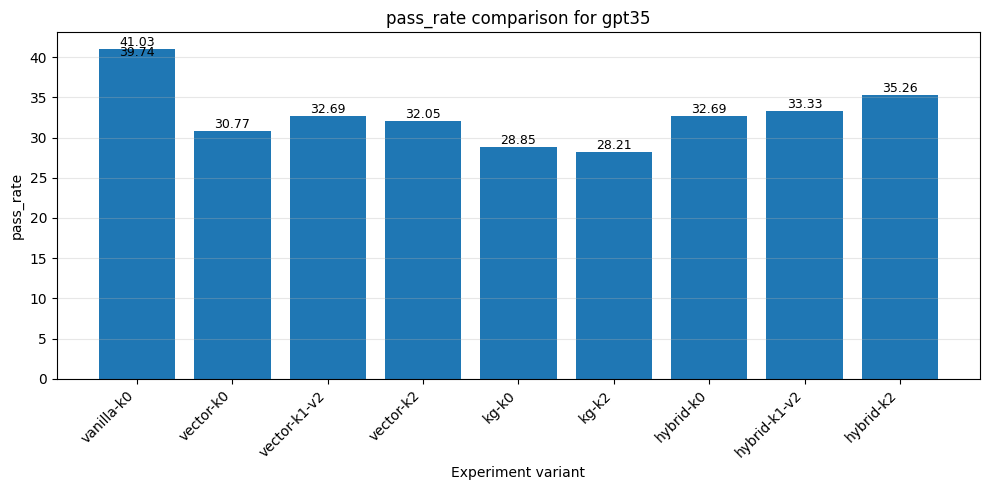

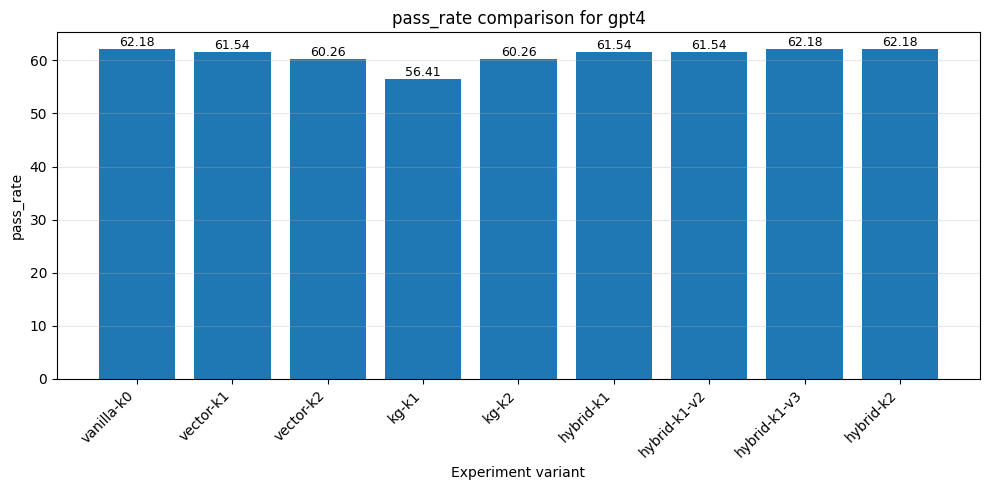

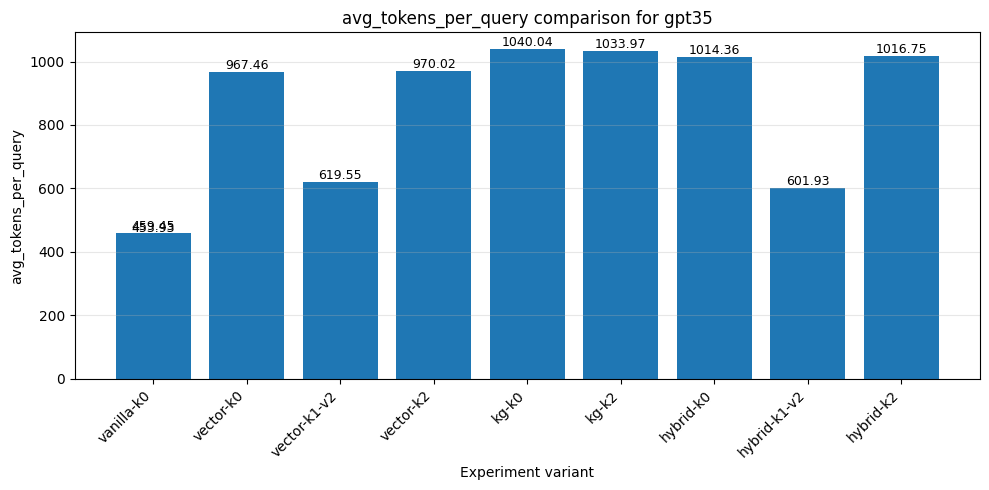

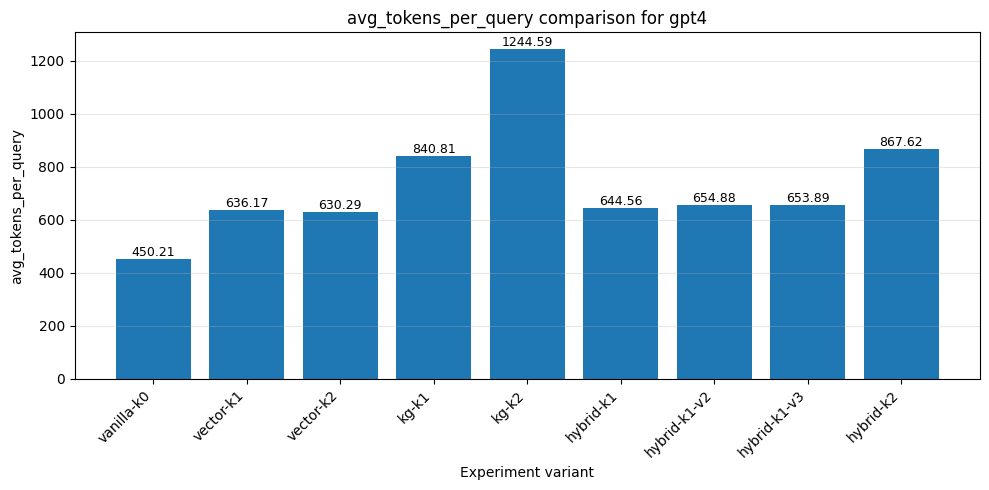

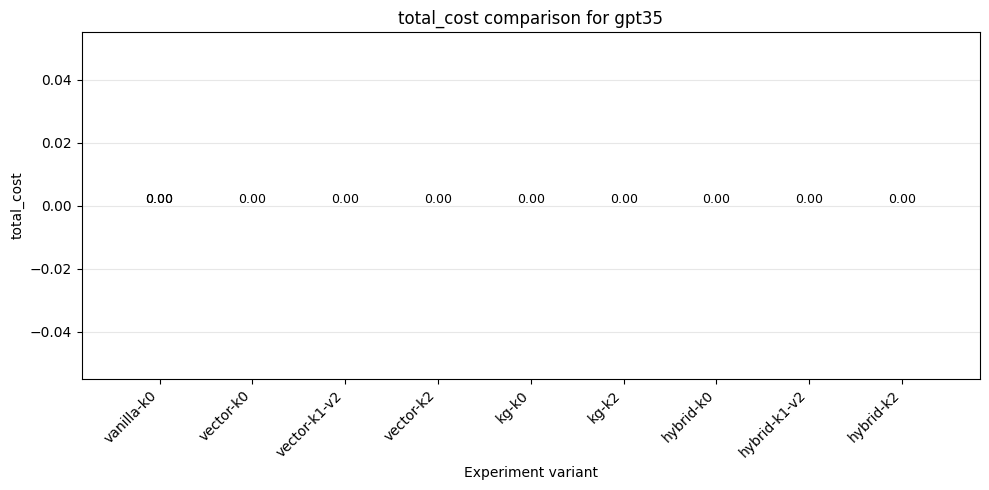

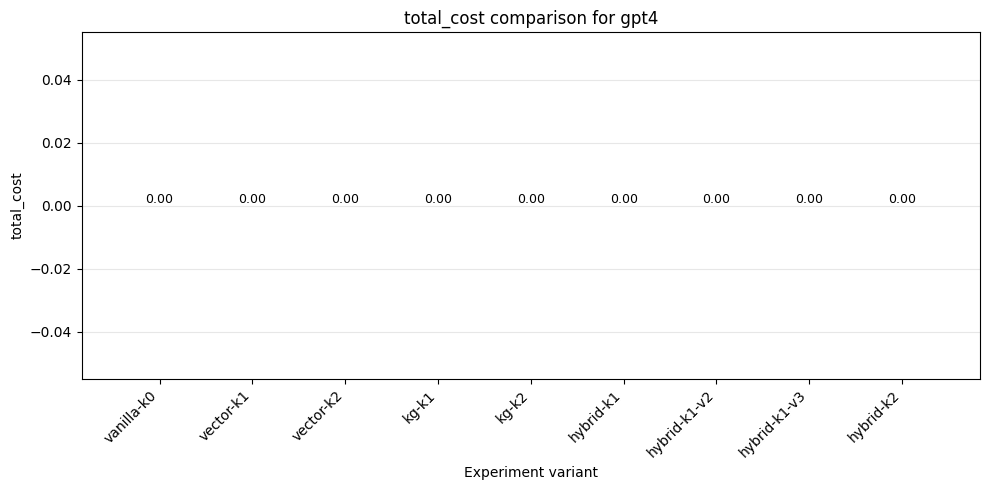

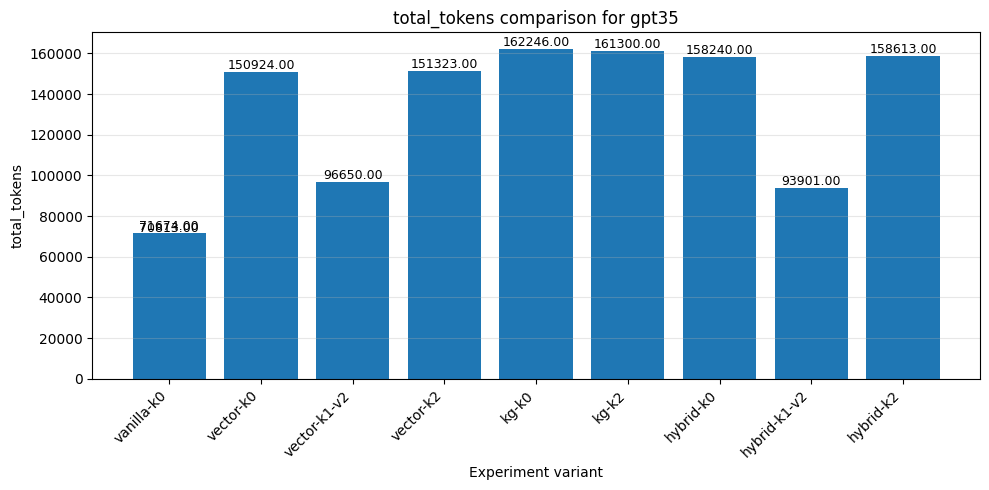

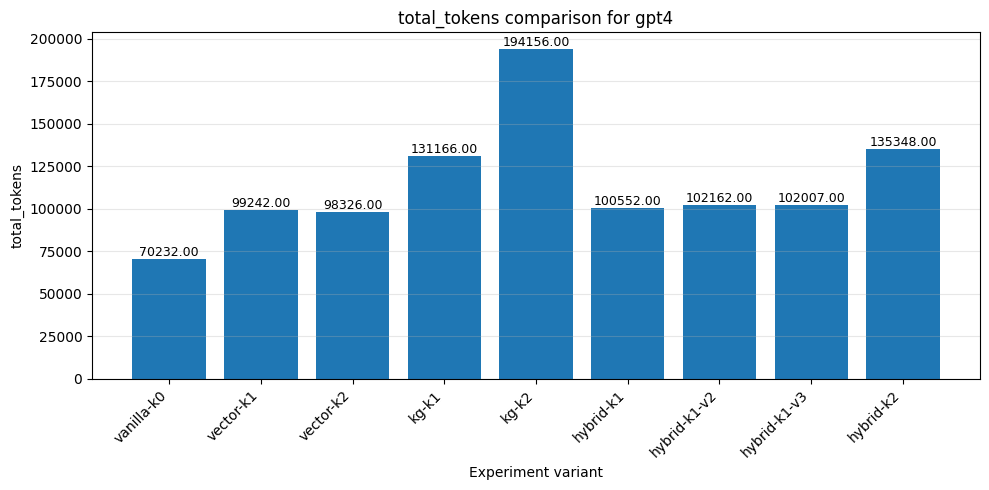

In [4]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================================================
# 1) CONFIG
# =========================================================

root = Path("verilog-eval-wsl")
build_dir = root / "build"

# Adjust this if you want to restrict which folders are included
include_prefixes = [
    "openrouter-gpt4-full-",
    "openrouter-gpt35-full-",
]

metrics_to_extract = [
    "pass_rate",
    "avg_gini_simpson_idx",
    "total_prompt_tokens",
    "total_resp_tokens",
    "total_tokens",
    "avg_tokens_per_prompt",
    "avg_tokens_per_resp",
    "avg_tokens_per_query",
    "total_cost",
]

# =========================================================
# 2) PARSE summary.txt
# =========================================================

def parse_summary_file(summary_path: Path):
    text = summary_path.read_text(encoding="utf-8", errors="ignore")

    results = {"summary_file": str(summary_path)}

    for metric in metrics_to_extract:
        pattern = rf"{metric}\s*=\s*([0-9]+(?:\.[0-9]+)?)"
        match = re.search(pattern, text)
        results[metric] = float(match.group(1)) if match else None

    return results

# =========================================================
# 3) PARSE FOLDER NAME
#    Example:
#    openrouter-gpt4-full-hybrid-k1-v2
# =========================================================

def parse_experiment_folder_name(folder_name: str):
    pattern = re.compile(
        r"^openrouter-(?P<model>gpt4|gpt35)-full-(?P<method>vanilla|vector|kg|hybrid)"
        r"(?:-k(?P<k>\d+))?"
        r"(?:-(?P<variant>v\d+))?$"
    )
    m = pattern.match(folder_name)
    if not m:
        return None

    info = m.groupdict()
    info["k"] = int(info["k"]) if info["k"] is not None else 0
    info["variant"] = info["variant"] if info["variant"] is not None else "base"
    return info

# =========================================================
# 4) FIND VALID EXPERIMENT FOLDERS
# =========================================================

rows = []

for folder in sorted(build_dir.iterdir()):
    if not folder.is_dir():
        continue

    if not any(folder.name.startswith(p) for p in include_prefixes):
        continue

    parsed_name = parse_experiment_folder_name(folder.name)
    if parsed_name is None:
        continue

    summary_file = folder / "summary.txt"
    if not summary_file.exists():
        print(f"WARNING: summary.txt not found in {folder}")
        continue

    parsed_summary = parse_summary_file(summary_file)

    row = {
        "folder_name": folder.name,
        "folder_path": str(folder),
        **parsed_name,
        **parsed_summary,
    }

    # Nice label for plotting
    if row["method"] == "vanilla":
        row["label"] = "vanilla-k0"
    else:
        row["label"] = f"{row['method']}-k{row['k']}"
        if row["variant"] != "base":
            row["label"] += f"-{row['variant']}"

    rows.append(row)

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("No valid experiment folders found.")

method_order = ["vanilla", "vector", "kg", "hybrid"]
model_order = ["gpt35", "gpt4"]

df["method"] = pd.Categorical(df["method"], categories=method_order, ordered=True)
df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)

df = df.sort_values(["model", "method", "k", "variant"]).reset_index(drop=True)

print("Parsed experiment summary table:")
display(df)

# =========================================================
# 5) PLOTTING
# =========================================================

def plot_metric_for_each_model(df, metric, ylabel=None):
    ylabel = ylabel or metric

    models_present = [m for m in model_order if m in df["model"].astype(str).unique()]

    for model in models_present:
        sub = df[df["model"].astype(str) == model].copy()
        sub = sub.dropna(subset=[metric])

        if sub.empty:
            print(f"No data for model={model}, metric={metric}")
            continue

        plt.figure(figsize=(10, 5))
        bars = plt.bar(sub["label"], sub[metric])

        plt.title(f"{metric} comparison for {model}")
        plt.xlabel("Experiment variant")
        plt.ylabel(ylabel)
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y", alpha=0.3)

        ymax = sub[metric].max()
        for bar, val in zip(bars, sub[metric]):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.tight_layout()
        plt.show()

# Choose the metrics you want to visualize
metrics_to_plot = [
    "pass_rate",
    "avg_tokens_per_query",
    "total_cost",
    "total_tokens",
]

for metric in metrics_to_plot:
    plot_metric_for_each_model(df, metric)

GROUP: GPT-4-Turbo | K=2 | VeriRAG Dataset


,summary_file,pass_rate,avg_gini_simpson_idx,total_prompt_tokens,total_resp_tokens,total_tokens,avg_tokens_per_prompt,avg_tokens_per_resp,avg_tokens_per_query,total_cost,architecture,folder,group
0,verilog-eval-wsl\build\openrouter-gpt4-full-va...,62.18,0.0,42750.0,27482.0,70232.0,274.04,176.17,450.21,0.0,vanilla,verilog-eval-wsl\build\openrouter-gpt4-full-va...,GPT-4-Turbo | K=2 | VeriRAG Dataset
1,verilog-eval-wsl\build\openrouter-gpt4-full-ve...,64.10,0.0,42750.0,27446.0,70196.0,274.04,175.94,449.97,0.0,vector,verilog-eval-wsl\build\openrouter-gpt4-full-ve...,GPT-4-Turbo | K=2 | VeriRAG Dataset
2,verilog-eval-wsl\build\openrouter-gpt4-full-kg...,65.38,0.0,114198.0,27228.0,141426.0,732.04,174.54,906.58,0.0,kg,verilog-eval-wsl\build\openrouter-gpt4-full-kg...,GPT-4-Turbo | K=2 | VeriRAG Dataset
3,verilog-eval-wsl\build\openrouter-gpt4-full-hy...,62.82,0.0,42750.0,27087.0,69837.0,274.04,173.63,447.67,0.0,hybrid,verilog-eval-wsl\build\openrouter-gpt4-full-hy...,GPT-4-Turbo | K=2 | VeriRAG Dataset


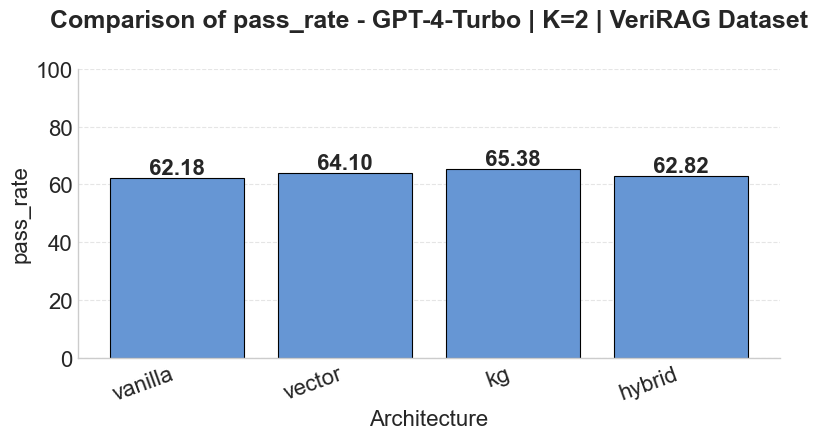

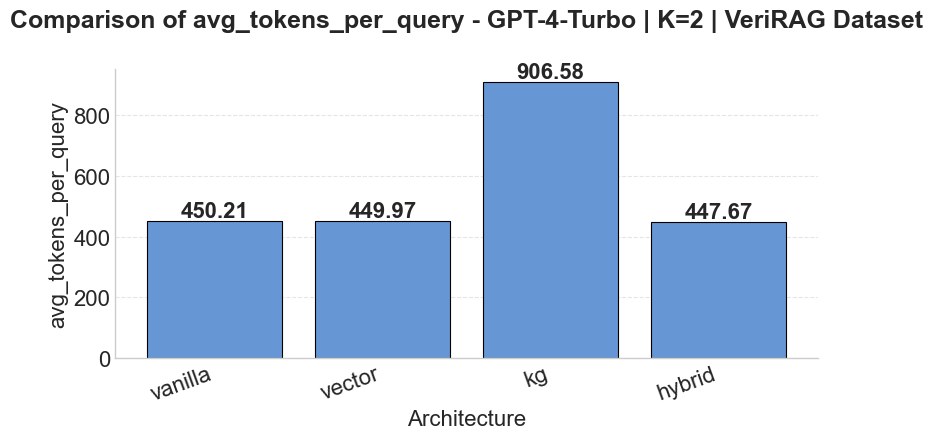

GROUP: gpt4_k2_set


,summary_file,pass_rate,avg_gini_simpson_idx,total_prompt_tokens,total_resp_tokens,total_tokens,avg_tokens_per_prompt,avg_tokens_per_resp,avg_tokens_per_query,total_cost,architecture,folder,group
0,verilog-eval-wsl\build\openrouter-gpt4-full-va...,62.18,0.0,42750.0,27482.0,70232.0,274.04,176.17,450.21,0.0,vanilla,verilog-eval-wsl\build\openrouter-gpt4-full-va...,gpt4_k2_set
1,verilog-eval-wsl\build\openrouter-gpt4-full-ve...,60.26,0.0,70909.0,27417.0,98326.0,454.54,175.75,630.29,0.0,vector,verilog-eval-wsl\build\openrouter-gpt4-full-ve...,gpt4_k2_set
2,verilog-eval-wsl\build\openrouter-gpt4-full-kg...,60.26,0.0,167209.0,26947.0,194156.0,1071.85,172.74,1244.59,0.0,kg,verilog-eval-wsl\build\openrouter-gpt4-full-kg-k2,gpt4_k2_set
3,verilog-eval-wsl\build\openrouter-gpt4-full-hy...,62.18,0.0,107348.0,28000.0,135348.0,688.13,179.49,867.62,0.0,hybrid,verilog-eval-wsl\build\openrouter-gpt4-full-hy...,gpt4_k2_set


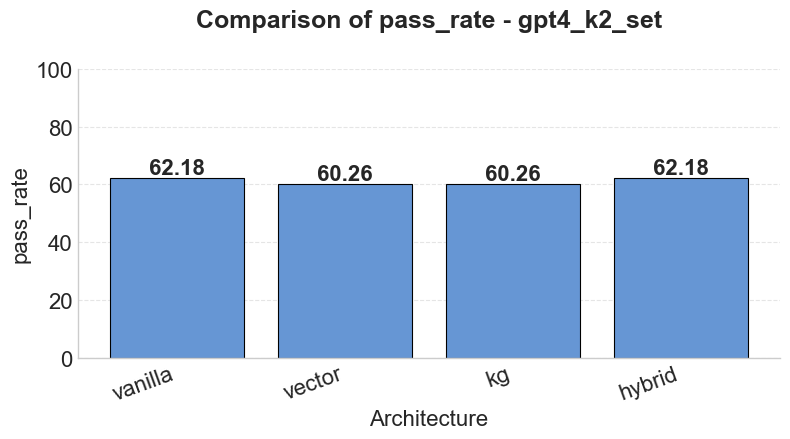

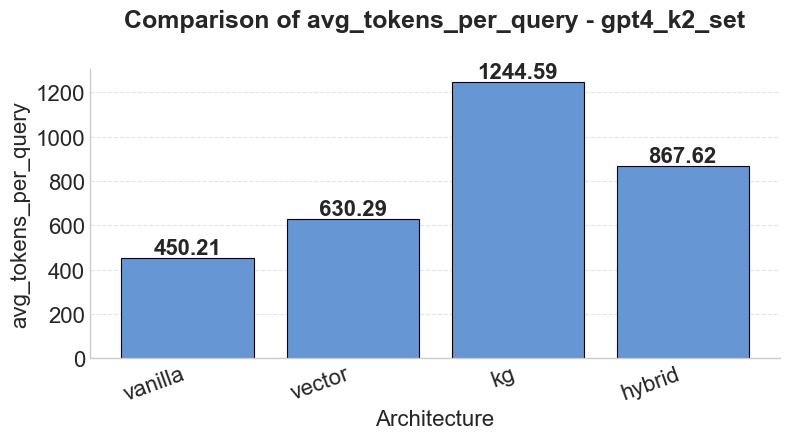

GROUP: gpt4_k1_set


,summary_file,pass_rate,avg_gini_simpson_idx,total_prompt_tokens,total_resp_tokens,total_tokens,avg_tokens_per_prompt,avg_tokens_per_resp,avg_tokens_per_query,total_cost,architecture,folder,group
0,verilog-eval-wsl\build\openrouter-gpt4-full-va...,62.18,0.0,42750.0,27482.0,70232.0,274.04,176.17,450.21,0.0,vanilla,verilog-eval-wsl\build\openrouter-gpt4-full-va...,gpt4_k1_set
1,verilog-eval-wsl\build\openrouter-gpt4-full-ve...,61.54,0.0,71227.0,28015.0,99242.0,456.58,179.58,636.17,0.0,vector,verilog-eval-wsl\build\openrouter-gpt4-full-ve...,gpt4_k1_set
2,verilog-eval-wsl\build\openrouter-gpt4-full-kg...,56.41,0.0,103021.0,28145.0,131166.0,660.39,180.42,840.81,0.0,kg,verilog-eval-wsl\build\openrouter-gpt4-full-kg-k1,gpt4_k1_set
3,verilog-eval-wsl\build\openrouter-gpt4-full-hy...,62.18,0.0,74325.0,27682.0,102007.0,476.44,177.45,653.89,0.0,hybrid,verilog-eval-wsl\build\openrouter-gpt4-full-hy...,gpt4_k1_set


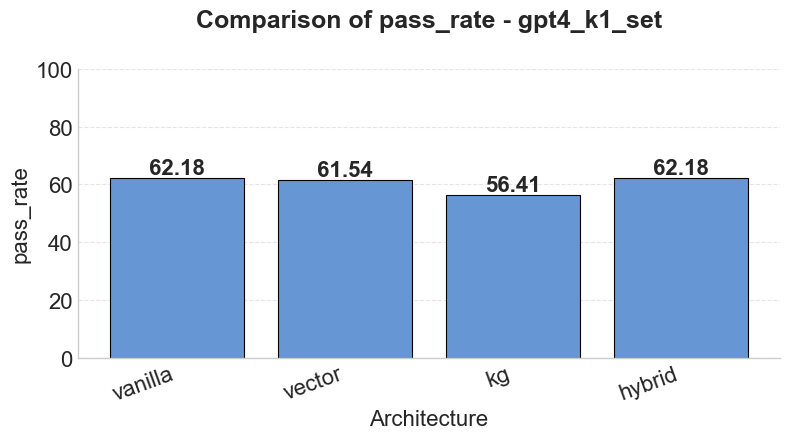

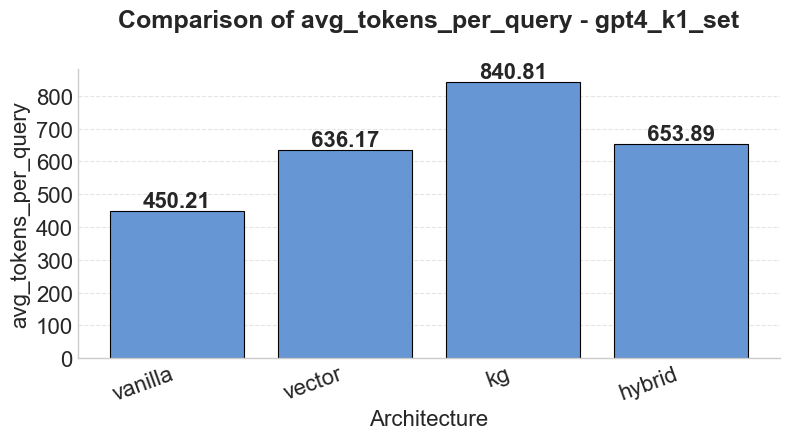

GROUP: gpt4_k2_set_d2


,summary_file,pass_rate,avg_gini_simpson_idx,total_prompt_tokens,total_resp_tokens,total_tokens,avg_tokens_per_prompt,avg_tokens_per_resp,avg_tokens_per_query,total_cost,architecture,folder,group
0,verilog-eval-wsl\build\openrouter-gpt4-full-va...,62.18,0.0,42750.0,27482.0,70232.0,274.04,176.17,450.21,0.0,vanilla,verilog-eval-wsl\build\openrouter-gpt4-full-va...,gpt4_k2_set_d2
1,verilog-eval-wsl\build\openrouter-gpt4-full-ve...,64.10,0.0,42750.0,27446.0,70196.0,274.04,175.94,449.97,0.0,vector,verilog-eval-wsl\build\openrouter-gpt4-full-ve...,gpt4_k2_set_d2
2,verilog-eval-wsl\build\openrouter-gpt4-full-kg...,62.18,0.0,114198.0,27506.0,141704.0,732.04,176.32,908.36,0.0,kg,verilog-eval-wsl\build\openrouter-gpt4-full-kg...,gpt4_k2_set_d2
3,verilog-eval-wsl\build\openrouter-gpt4-full-hy...,62.82,0.0,42750.0,27087.0,69837.0,274.04,173.63,447.67,0.0,hybrid,verilog-eval-wsl\build\openrouter-gpt4-full-hy...,gpt4_k2_set_d2


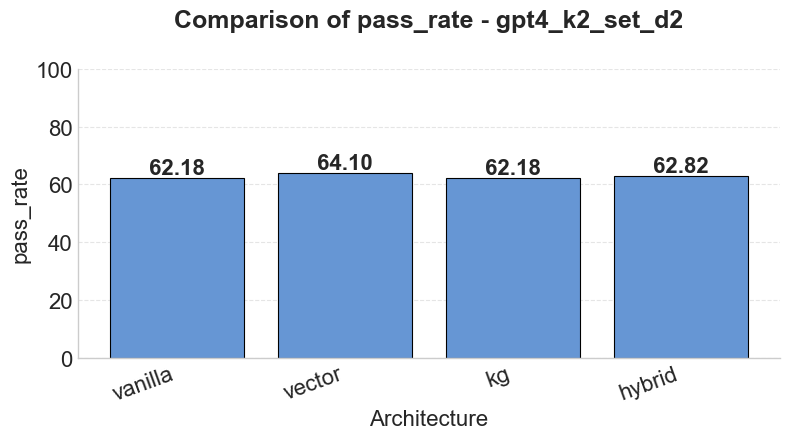

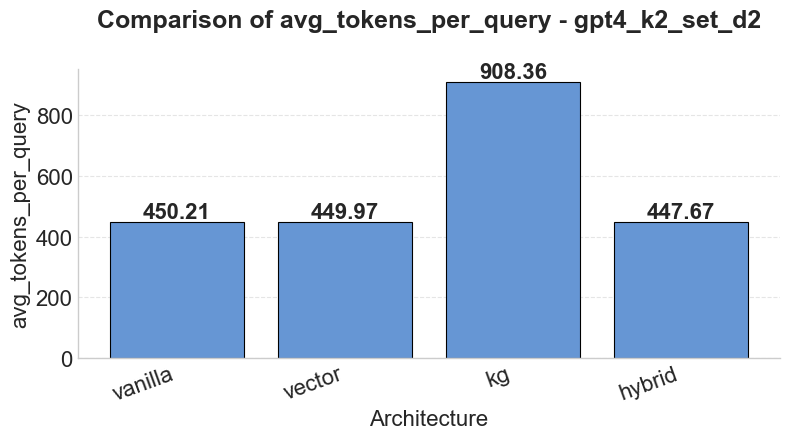

GROUP: gpt4_k2_set_d2_run2


,summary_file,pass_rate,avg_gini_simpson_idx,total_prompt_tokens,total_resp_tokens,total_tokens,avg_tokens_per_prompt,avg_tokens_per_resp,avg_tokens_per_query,total_cost,architecture,folder,group
0,verilog-eval-wsl\build\openrouter-gpt4-full-va...,64.10,0.0,42750.0,27232.0,69982.0,274.04,174.56,448.60,0.0,vanilla,verilog-eval-wsl\build\openrouter-gpt4-full-va...,gpt4_k2_set_d2_run2
1,verilog-eval-wsl\build\openrouter-gpt4-full-ve...,64.10,0.0,42750.0,27637.0,70387.0,274.04,177.16,451.20,0.0,vector,verilog-eval-wsl\build\openrouter-gpt4-full-ve...,gpt4_k2_set_d2_run2
2,verilog-eval-wsl\build\openrouter-gpt4-full-kg...,65.38,0.0,114198.0,27228.0,141426.0,732.04,174.54,906.58,0.0,kg,verilog-eval-wsl\build\openrouter-gpt4-full-kg...,gpt4_k2_set_d2_run2
3,verilog-eval-wsl\build\openrouter-gpt4-full-hy...,62.18,0.0,42750.0,27855.0,70605.0,274.04,178.56,452.60,0.0,hybrid,verilog-eval-wsl\build\openrouter-gpt4-full-hy...,gpt4_k2_set_d2_run2


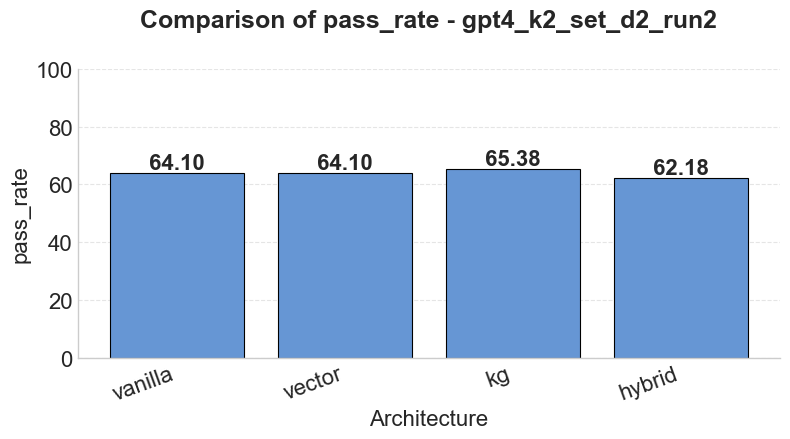

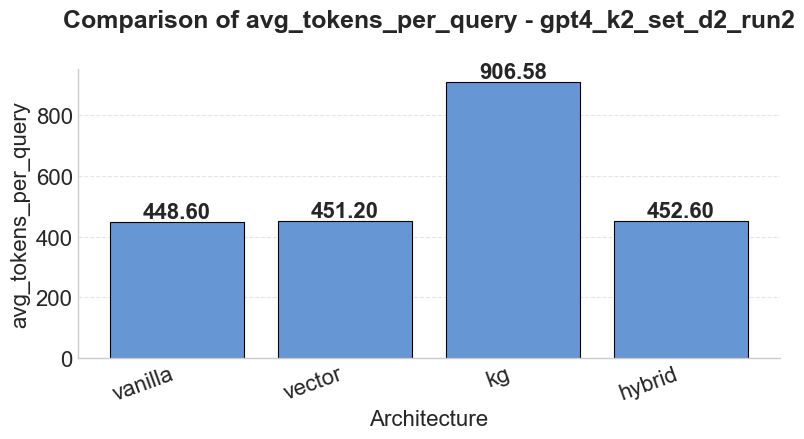

GROUP: gpt35_k2_set


,summary_file,pass_rate,avg_gini_simpson_idx,total_prompt_tokens,total_resp_tokens,total_tokens,avg_tokens_per_prompt,avg_tokens_per_resp,avg_tokens_per_query,total_cost,architecture,folder,group
0,verilog-eval-wsl\build\openrouter-gpt35-full-v...,39.74,0.0,42750.0,28924.0,71674.0,274.04,185.41,459.45,0.0,vanilla,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35_k2_set
1,verilog-eval-wsl\build\openrouter-gpt35-full-v...,32.05,0.0,119709.0,31614.0,151323.0,767.37,202.65,970.02,0.0,vector,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35_k2_set
2,verilog-eval-wsl\build\openrouter-gpt35-full-k...,28.21,0.0,133051.0,28249.0,161300.0,852.89,181.08,1033.97,0.0,kg,verilog-eval-wsl\build\openrouter-gpt35-full-k...,gpt35_k2_set
3,verilog-eval-wsl\build\openrouter-gpt35-full-h...,35.26,0.0,128788.0,29825.0,158613.0,825.56,191.19,1016.75,0.0,hybrid,verilog-eval-wsl\build\openrouter-gpt35-full-h...,gpt35_k2_set


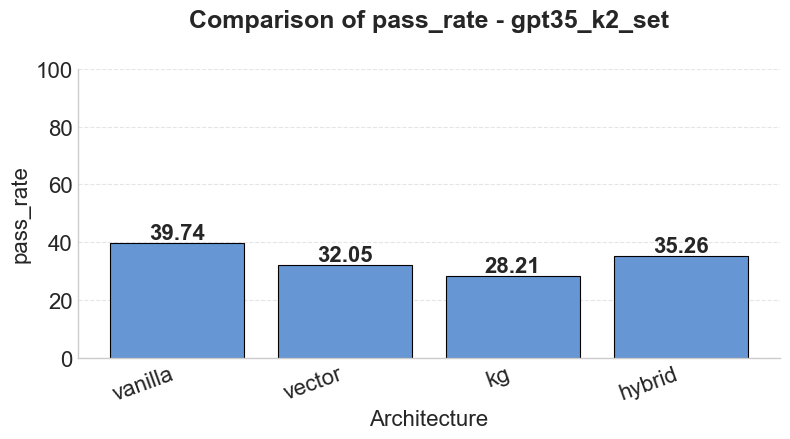

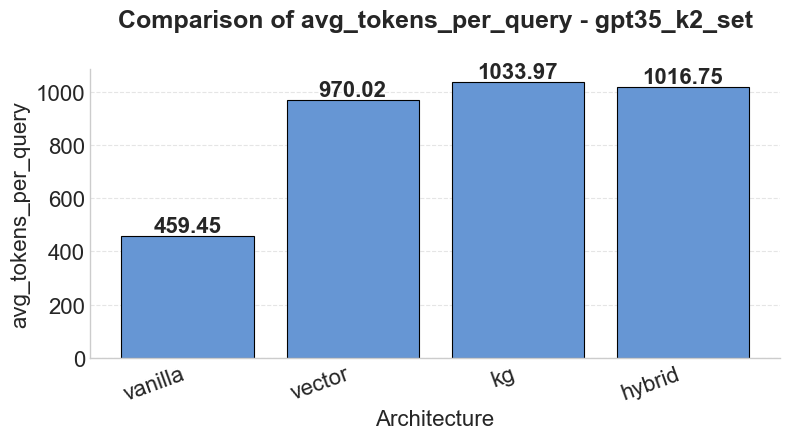

GROUP: gpt35_k1_set


,summary_file,pass_rate,avg_gini_simpson_idx,total_prompt_tokens,total_resp_tokens,total_tokens,avg_tokens_per_prompt,avg_tokens_per_resp,avg_tokens_per_query,total_cost,architecture,folder,group
0,verilog-eval-wsl\build\openrouter-gpt35-full-v...,39.74,0.0,42750.0,28924.0,71674.0,274.04,185.41,459.45,0.0,vanilla,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35_k1_set
1,verilog-eval-wsl\build\openrouter-gpt35-full-v...,32.69,0.0,66113.0,30537.0,96650.0,423.80,195.75,619.55,0.0,vector,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35_k1_set
2,verilog-eval-wsl\build\openrouter-gpt35-full-k...,28.21,0.0,133051.0,28249.0,161300.0,852.89,181.08,1033.97,0.0,kg,verilog-eval-wsl\build\openrouter-gpt35-full-k...,gpt35_k1_set
3,verilog-eval-wsl\build\openrouter-gpt35-full-h...,33.33,0.0,67127.0,26774.0,93901.0,430.30,171.63,601.93,0.0,hybrid,verilog-eval-wsl\build\openrouter-gpt35-full-h...,gpt35_k1_set


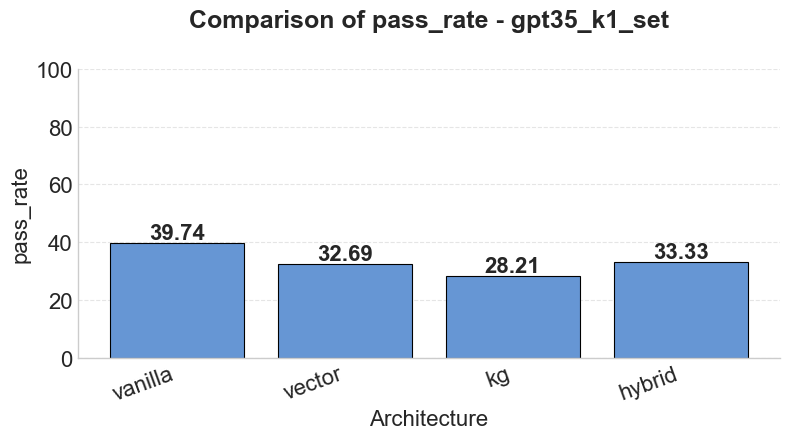

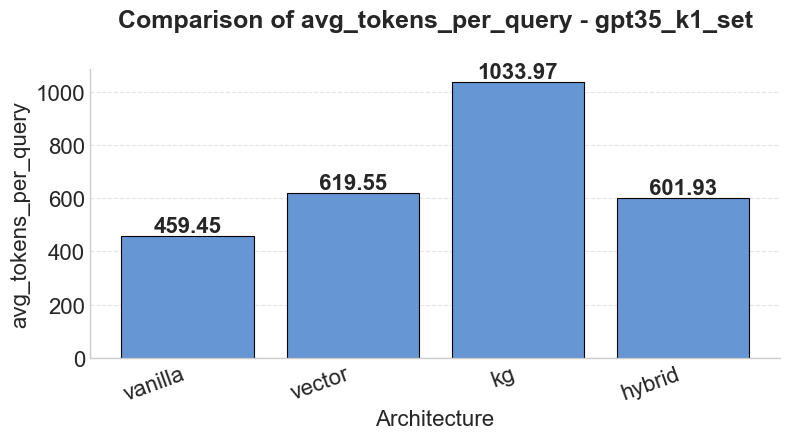

GROUP: gpt35_k0_set


,summary_file,pass_rate,avg_gini_simpson_idx,total_prompt_tokens,total_resp_tokens,total_tokens,avg_tokens_per_prompt,avg_tokens_per_resp,avg_tokens_per_query,total_cost,architecture,folder,group
0,verilog-eval-wsl\build\openrouter-gpt35-full-v...,39.74,0.0,42750.0,28924.0,71674.0,274.04,185.41,459.45,0.0,vanilla_run1,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35_k0_set
1,verilog-eval-wsl\build\openrouter-gpt35-full-v...,41.03,0.0,42750.0,28063.0,70813.0,274.04,179.89,453.93,0.0,vanilla_run2,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35_k0_set
2,verilog-eval-wsl\build\openrouter-gpt35-full-v...,37.18,0.0,42750.0,27322.0,70072.0,274.04,175.14,449.18,0.0,vanilla_run3,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35_k0_set
3,verilog-eval-wsl\build\openrouter-gpt35-full-v...,39.74,0.0,42750.0,27907.0,70657.0,274.04,178.89,452.93,0.0,vanilla_run4,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35_k0_set
4,verilog-eval-wsl\build\openrouter-gpt35-full-v...,41.03,0.0,42750.0,27331.0,70081.0,274.04,175.20,449.24,0.0,vanilla_run5,verilog-eval-wsl\build\openrouter-gpt35-full-v...,gpt35_k0_set


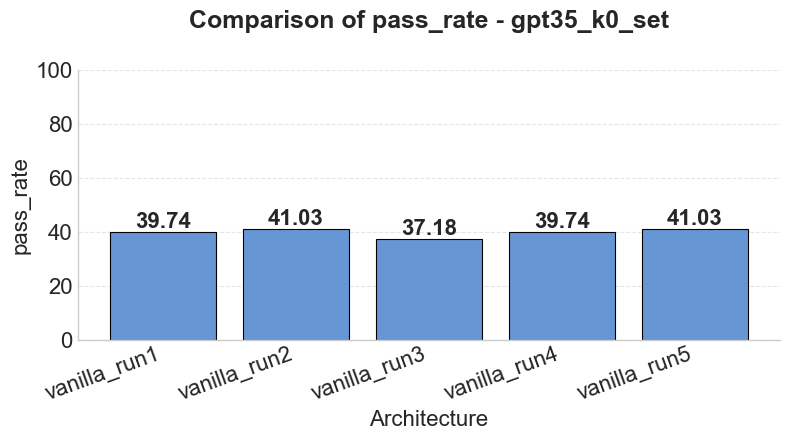

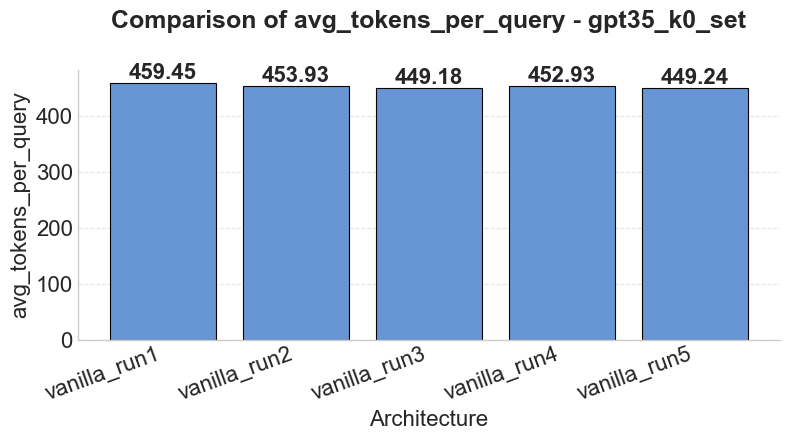

In [15]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================================================
# 1) ROOT
# =========================================================

root = Path("verilog-eval-wsl")

# =========================================================
# 2) DEFINE MULTIPLE GROUPS OF FOLDERS
#    Each top-level key is one comparison group
# =========================================================

selected_folder_groups = {
    "GPT-4-Turbo | K=2 | VeriRAG Dataset": {
        "vanilla": root / "build" / "openrouter-gpt4-full-vanilla-k0",
        "vector":  root / "build" / "openrouter-gpt4-full-vector-k2-d2",
        "kg":      root / "build" / "openrouter-gpt4-full-kg-k2-d2-run2",
        "hybrid":  root / "build" / "openrouter-gpt4-full-hybrid-k2-d2",
    },
    
    "gpt4_k2_set": {
        "vanilla": root / "build" / "openrouter-gpt4-full-vanilla-k0",
        "vector":  root / "build" / "openrouter-gpt4-full-vector-k2",
        "kg":      root / "build" / "openrouter-gpt4-full-kg-k2",
        "hybrid":  root / "build" / "openrouter-gpt4-full-hybrid-k2",
    },

    "gpt4_k1_set": {
        "vanilla": root / "build" / "openrouter-gpt4-full-vanilla-k0",
        "vector":  root / "build" / "openrouter-gpt4-full-vector-k1",
        "kg":      root / "build" / "openrouter-gpt4-full-kg-k1",
        "hybrid":  root / "build" / "openrouter-gpt4-full-hybrid-k1-v3",
    },

    "gpt4_k2_set_d2": {
        "vanilla": root / "build" / "openrouter-gpt4-full-vanilla-k0",
        "vector":  root / "build" / "openrouter-gpt4-full-vector-k2-d2",
        "kg":      root / "build" / "openrouter-gpt4-full-kg-k2-d2",
        "hybrid":  root / "build" / "openrouter-gpt4-full-hybrid-k2-d2",
    },

        "gpt4_k2_set_d2_run2": {
        "vanilla": root / "build" / "openrouter-gpt4-full-vanilla-run2",
        "vector":  root / "build" / "openrouter-gpt4-full-vector-k2-run2",
        "kg":      root / "build" / "openrouter-gpt4-full-kg-k2-d2-run2",
        "hybrid":  root / "build" / "openrouter-gpt4-full-hybrid-k2-d2-run2",
    },

    "gpt35_k2_set": {
        "vanilla": root / "build" / "openrouter-gpt35-full-vanilla-k0",
        "vector":  root / "build" / "openrouter-gpt35-full-vector-k2",
        "kg":      root / "build" / "openrouter-gpt35-full-kg-k2",
        "hybrid":  root / "build" / "openrouter-gpt35-full-hybrid-k2",
    },

    "gpt35_k1_set": {
        "vanilla": root / "build" / "openrouter-gpt35-full-vanilla-k0",
        "vector":  root / "build" / "openrouter-gpt35-full-vector-k1-v2",
        "kg":      root / "build" / "openrouter-gpt35-full-kg-k2",
        "hybrid":  root / "build" / "openrouter-gpt35-full-hybrid-k1-v2",
    },
    "gpt35_k0_set": {
        "vanilla_run1": root / "build" / "openrouter-gpt35-full-vanilla-k0",
        "vanilla_run2":  root / "build" / "openrouter-gpt35-full-vanilla",
        "vanilla_run3":  root / "build" / "openrouter-gpt35-full-vanilla-run1",
        "vanilla_run4":  root / "build" / "openrouter-gpt35-full-vanilla-run2",
        "vanilla_run5":  root / "build" / "openrouter-gpt35-full-vanilla-run3",
    },
}

# =========================================================
# 3) METRICS TO EXTRACT
# =========================================================

metrics_to_extract = [
    "pass_rate",
    "avg_gini_simpson_idx",
    "total_prompt_tokens",
    "total_resp_tokens",
    "total_tokens",
    "avg_tokens_per_prompt",
    "avg_tokens_per_resp",
    "avg_tokens_per_query",
    "total_cost",
]

# =========================================================
# 4) PARSE ONE summary.txt
# =========================================================

def parse_summary_file(summary_path: Path):
    text = summary_path.read_text(encoding="utf-8", errors="ignore")

    results = {"summary_file": str(summary_path)}

    for metric in metrics_to_extract:
        pattern = rf"{metric}\s*=\s*([0-9]+(?:\.[0-9]+)?)"
        match = re.search(pattern, text)
        results[metric] = float(match.group(1)) if match else None

    return results

# =========================================================
# 5) READ ONE GROUP
# =========================================================

def read_experiment_group(group_name, folder_dict):
    rows = []

    for label, folder in folder_dict.items():
        summary_file = folder / "summary.txt"

        if summary_file.exists():
            parsed = parse_summary_file(summary_file)
            parsed["architecture"] = label
            parsed["folder"] = str(folder)
            parsed["group"] = group_name
            rows.append(parsed)
        else:
            print(f"WARNING [{group_name}]: summary.txt not found in {folder}")

    df_group = pd.DataFrame(rows)

    if df_group.empty:
        print(f"WARNING: no valid summaries found for group '{group_name}'")
        return df_group

    return df_group.reset_index(drop=True)

# =========================================================
# 6) PLOT FUNCTION
# =========================================================

def bar_plot_with_labels(x, y, title, ylabel, ylim=None):
    plt.figure(figsize=(8, 4.5))

    # Use a clean style
    plt.style.use("seaborn-v0_8-whitegrid")

    bars = plt.bar(x, y, color="#6696D4", edgecolor="black", linewidth=0.8)

    # Titles and labels (larger + clearer)
    plt.title(title, fontsize=18, fontweight="bold", pad=30)
    plt.xlabel("Architecture", fontsize=16)
    plt.ylabel(ylabel, fontsize=16)

    # Axis ticks
    plt.xticks(rotation=20, ha="right", fontsize=16)
    plt.yticks(fontsize=16)

    # Limits
    if ylim is not None:
        plt.ylim(ylim)

    # Cleaner grid
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.grid(axis="x", visible=False)

    # Remove top/right spines (clean look)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Value labels (bigger + bold)
    for bar, val in zip(bars, y):
        if pd.notna(val):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=16,
                fontweight="bold"
            )

    plt.tight_layout()
    plt.show()

# =========================================================
# 7) PLOT ALL GROUPS SEPARATELY
# =========================================================

group_dfs = {}

for group_name, folder_dict in selected_folder_groups.items():
    print("=" * 80)
    print(f"GROUP: {group_name}")

    df_group = read_experiment_group(group_name, folder_dict)
    group_dfs[group_name] = df_group

    if df_group.empty:
        continue

    display(df_group)

    # ---- pass_rate plot ----
    max_pass = df_group["pass_rate"].max(skipna=True)
    pass_ylim_top = max(100, max_pass * 1.15) if pd.notna(max_pass) else 100

    bar_plot_with_labels(
        df_group["architecture"],
        df_group["pass_rate"],
        f"Comparison of pass_rate - {group_name}",
        "pass_rate",
        ylim=(0, pass_ylim_top)
    )

    # ---- avg_tokens_per_query plot ----
    bar_plot_with_labels(
        df_group["architecture"],
        df_group["avg_tokens_per_query"],
        f"Comparison of avg_tokens_per_query - {group_name}",
        "avg_tokens_per_query"
    )


In [7]:
import re
from pathlib import Path
import pandas as pd
from IPython.display import display

# =========================================================
# 1) REGEX FOR PER-PROBLEM LINES
#    Example line:
#    Prob001_zero [1/1](100.0%)
# =========================================================

SUMMARY_LINE_RE = re.compile(
    r"^(Prob\S+)\s+\[(\d+)/(\d+)\]\(\s*([0-9.]+)%\)",
    re.MULTILINE
)

ANSI_ESCAPE_RE = re.compile(r"\x1B[@-_][0-?]*[ -/]*[@-~]")

def clean_text(text: str) -> str:
    return ANSI_ESCAPE_RE.sub("", text)

def parse_problem_results(summary_path: Path) -> pd.DataFrame:
    if not summary_path.exists():
        raise FileNotFoundError(f"summary.txt not found: {summary_path}")

    text = clean_text(summary_path.read_text(encoding="utf-8", errors="ignore"))

    rows = []
    for match in SUMMARY_LINE_RE.finditer(text):
        problem = match.group(1)
        passed = int(match.group(2))
        total = int(match.group(3))
        pct = float(match.group(4))

        if total != 1:
            raise ValueError(
                f"{summary_path} contains total_count != 1 for {problem}. "
                "This code assumes samples=1."
            )

        pass1 = 1 if passed == 1 else 0

        rows.append({
            "problem": problem,
            "pass1": pass1,
            "passed_count": passed,
            "total_count": total,
            "pass_percent": pct,
        })

    if not rows:
        raise ValueError(f"No problem rows parsed from: {summary_path}")

    return pd.DataFrame(rows).sort_values("problem").reset_index(drop=True)

# =========================================================
# 2) REUSE df FROM CODE 1
#    Make sure Code 1 was run first
# =========================================================

if "df" not in globals():
    raise ValueError("Please run Code 1 first so the experiment dataframe 'df' exists.")

# =========================================================
# 3) FIND VANILLA BASELINES
# =========================================================

vanilla_df = df[df["method"].astype(str) == "vanilla"].copy()

if vanilla_df.empty:
    raise ValueError("No vanilla baselines found.")

def compare_variant_to_vanilla(vanilla_summary: Path, variant_summary: Path):
    vanilla = parse_problem_results(vanilla_summary)[["problem", "pass1"]].rename(
        columns={"pass1": "vanilla_pass1"}
    )
    variant = parse_problem_results(variant_summary)[["problem", "pass1"]].rename(
        columns={"pass1": "variant_pass1"}
    )

    merged = vanilla.merge(variant, on="problem", how="outer", indicator=True)

    only_in_vanilla = merged[merged["_merge"] == "left_only"]["problem"].tolist()
    only_in_variant = merged[merged["_merge"] == "right_only"]["problem"].tolist()

    common = merged[merged["_merge"] == "both"].copy()

    common["status"] = common.apply(
        lambda row:
            "passed_both" if row["vanilla_pass1"] == 1 and row["variant_pass1"] == 1 else
            "failed_both" if row["vanilla_pass1"] == 0 and row["variant_pass1"] == 0 else
            "improved_vs_vanilla" if row["vanilla_pass1"] == 0 and row["variant_pass1"] == 1 else
            "regressed_vs_vanilla",
        axis=1
    )

    same_result = (common["vanilla_pass1"] == common["variant_pass1"]).sum()
    different_result = (common["vanilla_pass1"] != common["variant_pass1"]).sum()

    vanilla_failed = set(common.loc[common["vanilla_pass1"] == 0, "problem"])
    variant_failed = set(common.loc[common["variant_pass1"] == 0, "problem"])

    overlap_failed = vanilla_failed & variant_failed
    union_failed = vanilla_failed | variant_failed
    failed_jaccard = len(overlap_failed) / len(union_failed) if union_failed else 1.0

    summary = {
        "problems_in_common": len(common),
        "only_in_vanilla": len(only_in_vanilla),
        "only_in_variant": len(only_in_variant),
        "same_result_count": same_result,
        "different_result_count": different_result,
        "same_result_rate": same_result / len(common) if len(common) else None,
        "passed_both": (common["status"] == "passed_both").sum(),
        "failed_both": (common["status"] == "failed_both").sum(),
        "improved_vs_vanilla": (common["status"] == "improved_vs_vanilla").sum(),
        "regressed_vs_vanilla": (common["status"] == "regressed_vs_vanilla").sum(),
        "failed_jaccard": failed_jaccard,
        "vanilla_pass_rate_common": common["vanilla_pass1"].mean() if len(common) else None,
        "variant_pass_rate_common": common["variant_pass1"].mean() if len(common) else None,
    }

    return summary, common.sort_values(["status", "problem"]).reset_index(drop=True)

# =========================================================
# 4) BUILD SUMMARY TABLE AGAINST VANILLA
# =========================================================

comparison_rows = []
detailed_results = {}

for _, variant_row in df.iterrows():
    model = str(variant_row["model"])
    method = str(variant_row["method"])
    label = variant_row["label"]

    # skip vanilla comparing to itself
    if method == "vanilla":
        continue

    vanilla_match = vanilla_df[vanilla_df["model"].astype(str) == model]
    if vanilla_match.empty:
        print(f"WARNING: no vanilla baseline found for model={model}")
        continue

    # assume one vanilla per model
    vanilla_summary = Path(vanilla_match.iloc[0]["summary_file"])
    variant_summary = Path(variant_row["summary_file"])

    summary_stats, detailed_df = compare_variant_to_vanilla(vanilla_summary, variant_summary)

    comparison_rows.append({
        "model": model,
        "variant_label": label,
        "variant_folder": variant_row["folder_name"],
        **summary_stats,
    })

    detailed_results[(model, label)] = detailed_df

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["model", "variant_label"]
).reset_index(drop=True)

print("Summary comparison table vs vanilla:")
display(comparison_df)

# =========================================================
# 5) OPTIONAL: VIEW DETAILED PER-PROBLEM TABLE FOR ONE VARIANT
# =========================================================

# Example:
#   detailed_results[("gpt4", "vector-k1")]
#   detailed_results[("gpt4", "hybrid-k1-v2")]
#   detailed_results[("gpt35", "kg-k2")]

example_key = next(iter(detailed_results.keys()))
print(f"Showing example detailed comparison for: {example_key}")
display(detailed_results[example_key])

# If you want a specific one, uncomment and edit:
# display(detailed_results[("gpt4", "vector-k2")])

Summary comparison table vs vanilla:


,model,variant_label,variant_folder,problems_in_common,only_in_vanilla,only_in_variant,same_result_count,different_result_count,same_result_rate,passed_both,failed_both,improved_vs_vanilla,regressed_vs_vanilla,failed_jaccard,vanilla_pass_rate_common,variant_pass_rate_common
0,gpt35,hybrid-k0,openrouter-gpt35-full-hybrid,156,0,0,125,31,0.801282,42,83,9,22,0.728070,0.410256,0.326923
1,gpt35,hybrid-k1-v2,openrouter-gpt35-full-hybrid-k1-v2,156,0,0,136,20,0.871795,48,88,4,16,0.814815,0.410256,0.333333
2,gpt35,hybrid-k2,openrouter-gpt35-full-hybrid-k2,156,0,0,127,29,0.814103,45,82,10,19,0.738739,0.410256,0.352564
3,gpt35,kg-k0,openrouter-gpt35-full-kg,156,0,0,125,31,0.801282,39,86,6,25,0.735043,0.410256,0.288462
4,gpt35,kg-k2,openrouter-gpt35-full-kg-k2,156,0,0,122,34,0.782051,37,85,7,27,0.714286,0.410256,0.282051
5,gpt35,vector-k0,openrouter-gpt35-full-vector,156,0,0,128,28,0.820513,42,86,6,22,0.754386,0.410256,0.307692
6,gpt35,vector-k1-v2,openrouter-gpt35-full-vector-k1-v2,156,0,0,135,21,0.865385,47,88,4,17,0.807339,0.410256,0.326923
7,gpt35,vector-k2,openrouter-gpt35-full-vector-k2,156,0,0,128,28,0.820513,43,85,7,21,0.752212,0.410256,0.320513
8,gpt4,hybrid-k1,openrouter-gpt4-full-hybrid-k1,156,0,0,147,9,0.942308,92,55,4,5,0.859375,0.621795,0.615385
9,gpt4,hybrid-k1-v2,openrouter-gpt4-full-hybrid-k1-v2,156,0,0,149,7,0.955128,93,56,3,4,0.888889,0.621795,0.615385


Showing example detailed comparison for: ('gpt35', 'vector-k0')


,problem,vanilla_pass1,variant_pass1,_merge,status
0,Prob002_m2014_q4i,0,0,both,failed_both
1,Prob003_step_one,0,0,both,failed_both
2,Prob008_m2014_q4h,0,0,both,failed_both
3,Prob018_mux256to1,0,0,both,failed_both
4,Prob021_mux256to1v,0,0,both,failed_both
...,...,...,...,...,...
151,Prob085_shift4,1,0,both,regressed_vs_vanilla
152,Prob090_circuit1,1,0,both,regressed_vs_vanilla
153,Prob097_mux9to1v,1,0,both,regressed_vs_vanilla
154,Prob103_circuit2,1,0,both,regressed_vs_vanilla


In [9]:
detailed_results[("gpt4", "vector-k2")]

,problem,vanilla_pass1,variant_pass1,_merge,status
0,Prob034_dff8,0,0,both,failed_both
1,Prob050_kmap1,0,0,both,failed_both
2,Prob053_m2014_q4d,0,0,both,failed_both
3,Prob057_kmap2,0,0,both,failed_both
4,Prob058_alwaysblock2,0,0,both,failed_both
...,...,...,...,...,...
151,Prob072_thermostat,1,0,both,regressed_vs_vanilla
152,Prob094_gatesv,1,0,both,regressed_vs_vanilla
153,Prob112_always_case2,1,0,both,regressed_vs_vanilla
154,Prob138_2012_q2fsm,1,0,both,regressed_vs_vanilla


## Mean / Variance Analysis

In [3]:
import numpy as np

# Data
pass_rate = [39.74, 41.03, 37.18, 39.74, 41.03]
tokens = [459.45, 453.93, 449.18, 452.93, 449.24]

# Pass rate stats
pass_mean = np.mean(pass_rate)
pass_var_pop = np.var(pass_rate)
pass_var_sample = np.var(pass_rate, ddof=1)
pass_std_pop = np.std(pass_rate)
pass_std_sample = np.std(pass_rate, ddof=1)

# Token stats
tokens_mean = np.mean(tokens)
tokens_var_pop = np.var(tokens)
tokens_var_sample = np.var(tokens, ddof=1)
tokens_std_pop = np.std(tokens)
tokens_std_sample = np.std(tokens, ddof=1)

print("Pass Rate Mean:", pass_mean)
print("Pass Rate Variance (population):", pass_var_pop)
print("Pass Rate Variance (sample):", pass_var_sample)
print("Pass Rate Std (population):", pass_std_pop)
print("Pass Rate Std (sample):", pass_std_sample)

print("\nTokens Mean:", tokens_mean)
print("Tokens Variance (population):", tokens_var_pop)
print("Tokens Variance (sample):", tokens_var_sample)
print("Tokens Std (population):", tokens_std_pop)
print("Tokens Std (sample):", tokens_std_sample)

Pass Rate Mean: 39.74400000000001
Pass Rate Variance (population): 1.9763440000000014
Pass Rate Variance (sample): 2.4704300000000017
Pass Rate Std (population): 1.405825024674124
Pass Rate Std (sample): 1.5717601598208302

Tokens Mean: 452.946
Tokens Variance (population): 14.237543999999948
Tokens Variance (sample): 17.796929999999936
Tokens Std (population): 3.7732670194408384
Tokens Std (sample): 4.218640776363868
